# Data Center Infrastructure Monitoring Pipeline

## Overview

Infrastructure telemetry — CPU utilization, network throughput, disk I/O — is only useful if it
reaches analysts, dashboards, and downstream models in a clean, trustworthy, queryable form. In
practice, that telemetry arrives from many servers, in different formats, at different volumes, and
with the ordinary defects of real sensor data: dropped readings, duplicated reports, occasional
corrupted values. This notebook builds the pipeline that turns that raw, messy multi-source telemetry
into a validated, query-ready warehouse.

## What this notebook covers

The project follows the stages of a real data engineering pipeline, in order:

**Extract → Validate → Transform → Load → Orchestrate → Monitor → Downstream Consumption → Conclusion**

Each stage is implemented, explained, and run against real data — not a toy example. Specifically:

- **Extract**: a config-driven ingestion layer that reads from a source registry, so new servers can
  be onboarded without code changes
- **Validate**: an explicit data-quality gate that catches duplicate readings, nulls, and out-of-range
  values before they reach the warehouse — demonstrated against both real defects found in the data
  and deliberately injected test cases
- **Transform**: gap-filling to a regular time grid, plus feature engineering (rolling statistics)
  that turns raw readings into monitoring-ready signals
- **Load**: a star-schema warehouse (dimension/fact tables), the standard pattern for BI-facing
  analytical systems
- **Orchestrate**: a production-grade Airflow DAG for scheduled, unattended execution with retries
  and failure alerting
- **Monitor**: a pipeline run log that makes the pipeline's own health queryable, plus a real bug
  caught during development and left in the write-up as a worked example of why that log matters
- **Downstream Consumption**: a brief demonstration of the warehouse output feeding an anomaly-flagging
  use case, showing the pipeline's actual purpose — being consumed by something else

## The data

This uses **real production server telemetry** — not synthetic data — sourced from the Numenta
Anomaly Benchmark (NAB), a widely-used public benchmark of genuine AWS CloudWatch metrics:

| Source file | Metric | Simulated asset | Site |
|---|---|---|---|
| `ec2_cpu_utilization.csv` | CPU utilization (%) | EC2-WEB-04 | AWS us-east-1 |
| `ec2_network_in.csv` | Network in (bytes) | EC2-API-11 | AWS us-east-1 |
| `ec2_disk_write_bytes.csv` | Disk write (bytes) | EC2-DB-02 | AWS us-west-2 |
| `rds_cpu_utilization.csv` | CPU utilization (%) | RDS-PROD-01 | AWS us-east-1 |

The "asset" names, sites, and racks are a simulated inventory layer added on top of the real metric
values, so the pipeline has a realistic dimension table to join against — exactly the kind of
asset-registry join a real infrastructure monitoring system would need.

Note that these four sources cover **different, non-overlapping time windows** (February, March, and
April 2014). This is a real property of the source data, and it's a genuinely useful complication: it
means these sources *can't* naively be joined into one wide table on a shared timestamp column — a
real data engineering decision point this notebook works through explicitly, resolved by using a
long-format fact table instead (see Section 4).

## How to run this

See `README.md` in this repository for setup instructions and repository structure. In short:
install `requirements.txt`, then run every cell top to bottom. The pipeline is deterministic — the
figures reported throughout this notebook (row counts, rejected records, gaps filled) will reproduce
exactly on any re-run against the included data.

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import os
import time
from datetime import datetime, timezone
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
RAW_DIR = "data/raw"
DB_PATH = "warehouse/infra_monitoring.db"
os.makedirs("warehouse", exist_ok=True)

## 1. Extract

Real-world ingestion is rarely "read one CSV." It's usually many sources, each with its own format,
naming convention, and update cadence. That's modeled with a **source registry**: a config file that
maps each raw file to the asset metadata it represents.

This registry lives in `config/sources.yaml`, not hardcoded in this notebook. That distinction
matters: a dict written directly in the code still requires editing and redeploying the pipeline to
onboard a new server. Externalizing it to a config file means an on-call engineer -- or a non-engineer
following a runbook -- can register a new source by editing YAML, with no code change and no
redeploy. This is the actual point of "config-driven"; keeping the registry inside the script would
only have looked config-driven.

In [ ]:
import yaml

with open("config/sources.yaml") as f:
    SOURCE_REGISTRY = yaml.safe_load(f)["sources"]

print(f"Loaded {len(SOURCE_REGISTRY)} source(s) from config/sources.yaml")
for fname, meta in SOURCE_REGISTRY.items():
    print(f"  {fname} -> {meta['asset_id']} ({meta['site']})")

def extract():
    """Read every registered source file and tag each row with its asset/metric identity."""
    frames = []
    for fname, meta in SOURCE_REGISTRY.items():
        path = os.path.join(RAW_DIR, fname)
        df = pd.read_csv(path, parse_dates=["timestamp"])
        df["asset_id"] = meta["asset_id"]
        df["metric_type"] = meta["metric_type"]
        df["source_file"] = fname
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

raw = extract()
print(f"\nExtracted {len(raw):,} rows from {len(SOURCE_REGISTRY)} sources")
raw.groupby("asset_id")["timestamp"].agg(["min", "max", "count"])

Loaded 4 source(s) from config/sources.yaml
  ec2_cpu_utilization.csv -> EC2-WEB-04 (AWS-us-east-1)
  ec2_network_in.csv -> EC2-API-11 (AWS-us-east-1)
  ec2_disk_write_bytes.csv -> EC2-DB-02 (AWS-us-west-2)
  rds_cpu_utilization.csv -> RDS-PROD-01 (AWS-us-east-1)

Extracted 16,826 rows from 4 sources


,min,max,count
asset_id,,,
EC2-API-11,2014-04-10 00:04:00,2014-04-24 00:09:00,4032
EC2-DB-02,2014-03-01 17:34:00,2014-03-18 03:39:00,4730
EC2-WEB-04,2014-02-14 14:30:00,2014-02-28 14:25:00,4032
RDS-PROD-01,2014-02-14 14:30:00,2014-02-28 14:30:00,4032


**Observation:** each asset's data covers a different window (Feb 14–28, Mar 1–18, Apr 10–24).
This confirms the "high variety" problem in practice -- these sources genuinely cannot be merged on a
shared timestamp axis. The architecture below (a long-format fact table keyed by `asset_id` +
`timestamp`, rather than one wide table) is chosen specifically to handle this, and is also how this
scales cleanly to the 5th, 50th, or 500th server without changing the schema.

## 2. Validate

This is the data quality gate: no raw data reaches the warehouse without passing explicit checks.
Three checks are implemented here, chosen to match failure modes that actually occur in telemetry
data: **duplicate readings** (a sensor or agent double-reporting), **nulls** (a dropped reading), and
**out-of-range values** (a corrupted or garbage sensor reading -- e.g. a CPU percentage that isn't
between 0 and 100).

To *prove* the out-of-range and null checks actually work -- rather than just trusting that they would
-- three synthetic bad rows are deliberately injected below. This is a standard QA practice: you don't
know a validation gate works until you've watched it catch something you know is bad. These three rows
are clearly separated from the real dataset (tagged `SYNTHETIC_INJECTED`) and are not used anywhere
else in the notebook.

In [ ]:
VALID_RANGES = {
    "cpu_utilization_pct": (0, 100),
    "network_in_bytes": (0, None),
    "disk_write_bytes": (0, None),
}

def inject_synthetic_corruption(raw):
    """
    Adds 3 known-bad rows to prove the validation gate catches real failure types
    (out-of-range values, a null reading). These are NOT part of the genuine
    AWS CloudWatch dataset -- tagged SYNTHETIC_INJECTED and excluded from every
    later analysis. Off-grid timestamps (:02:30) are used deliberately so they
    don't collide with real timestamps and get silently caught by the duplicate
    check instead of the check they're meant to test.
    """
    corrupt = pd.DataFrame([
        {"timestamp": pd.Timestamp("2014-02-20 12:02:30"), "value": 137.5, "asset_id": "EC2-WEB-04", "metric_type": "cpu_utilization_pct", "source_file": "SYNTHETIC_INJECTED"},
        {"timestamp": pd.Timestamp("2014-02-21 09:02:30"), "value": -12.0, "asset_id": "RDS-PROD-01", "metric_type": "cpu_utilization_pct", "source_file": "SYNTHETIC_INJECTED"},
        {"timestamp": pd.Timestamp("2014-04-15 03:02:30"), "value": np.nan, "asset_id": "EC2-API-11", "metric_type": "network_in_bytes", "source_file": "SYNTHETIC_INJECTED"},
    ])
    return pd.concat([raw, corrupt], ignore_index=True)

def validate(raw):
    """Applies the data quality gate. Returns (clean_df, issues_dict)."""
    issues = {"duplicates": 0, "nulls": 0, "out_of_range": 0}
    df = raw.copy()

    dup_mask = df.duplicated(subset=["asset_id", "timestamp"], keep="first")
    issues["duplicates"] = int(dup_mask.sum())
    df = df[~dup_mask]

    null_mask = df["value"].isna()
    issues["nulls"] = int(null_mask.sum())
    df = df[~null_mask]

    def out_of_range(row):
        lo, hi = VALID_RANGES.get(row["metric_type"], (None, None))
        v = row["value"]
        return (lo is not None and v < lo) or (hi is not None and v > hi)

    oor_mask = df.apply(out_of_range, axis=1)
    issues["out_of_range"] = int(oor_mask.sum())
    df = df[~oor_mask]

    return df, issues

raw_with_test_corruption = inject_synthetic_corruption(raw)
clean, issues = validate(raw_with_test_corruption)

print(f"Rows in:  {len(raw_with_test_corruption):,}")
print(f"Rows out: {len(clean):,}")
print(f"Rejected: {len(raw_with_test_corruption) - len(clean)}  -> {issues}")

Rows in:  16,829
Rows out: 16,815
Rejected: 14  -> {'duplicates': 11, 'nulls': 1, 'out_of_range': 2}


**Result:** the gate caught real duplicate readings that exist in the genuine dataset (11 of
them -- these are actual double-reported timestamps in the raw AWS data, found by this check, not
hypothetical), plus the injected out-of-range and null rows. This confirms the gate works against both
real and synthetic bad data before anything reaches the warehouse.

## 3. Transform

Two things happen here:

1. **Gap-filling to a regular grid.** Even after removing bad rows, telemetry data has small gaps
   (a reading that never arrived). Each asset's series is reindexed onto a strict 5-minute grid
   (matching the source cadence) and gaps are linearly interpolated. This is standard practice for
   time-series infra data -- downstream consumers (dashboards, alerting, ML models) expect a regular
   grid, not one with silent holes.
2. **Feature engineering for monitoring.** A 1-hour rolling mean/std and a rolling z-score are
   computed per asset. This turns raw readings into something a BI dashboard or alerting rule can act
   on directly (e.g. "flag anything with |z| > 3").

In [ ]:
def transform(clean):
    frames = []
    gaps_filled_total = 0
    for asset_id, g in clean.groupby("asset_id"):
        g = g.sort_values("timestamp").set_index("timestamp")
        full_range = pd.date_range(g.index.min(), g.index.max(), freq="5min")
        gaps_filled_total += len(full_range) - len(g)

        g = g.reindex(full_range)
        g["value"] = g["value"].interpolate(method="linear").ffill().bfill()
        g["asset_id"] = asset_id
        g["metric_type"] = g["metric_type"].ffill().bfill()
        g["source_file"] = g["source_file"].ffill().bfill()

        g["rolling_mean_1h"] = g["value"].rolling(12, min_periods=1).mean()
        g["rolling_std_1h"] = g["value"].rolling(12, min_periods=1).std().fillna(0)
        g["zscore_1h"] = (g["value"] - g["rolling_mean_1h"]) / g["rolling_std_1h"].replace(0, np.nan)
        g["zscore_1h"] = g["zscore_1h"].fillna(0)

        frames.append(g.reset_index().rename(columns={"index": "timestamp"}))

    return pd.concat(frames, ignore_index=True), gaps_filled_total

transformed, gaps_filled = transform(clean)
print(f"Gaps found and linearly filled: {gaps_filled}")
print(f"Rows after transform: {len(transformed):,}  (rows can increase vs. clean -- gap-filling adds grid points)")
transformed.head()

Gaps found and linearly filled: 14
Rows after transform: 16,829  (rows can increase vs. clean -- gap-filling adds grid points)


,timestamp,value,asset_id,metric_type,source_file,rolling_mean_1h,rolling_std_1h,zscore_1h
0,2014-04-10 00:04:00,"251,643.00",EC2-API-11,network_in_bytes,ec2_network_in.csv,"251,643.00",0.00,0.00
1,2014-04-10 00:09:00,"3,203,510.00",EC2-API-11,network_in_bytes,ec2_network_in.csv,"1,727,576.50","2,087,285.17",0.71
2,2014-04-10 00:14:00,"287,397.00",EC2-API-11,network_in_bytes,ec2_network_in.csv,"1,247,516.67","1,694,034.25",-0.57
3,2014-04-10 00:19:00,"238,944.00",EC2-API-11,network_in_bytes,ec2_network_in.csv,"995,373.50","1,472,233.92",-0.51
4,2014-04-10 00:24:00,"245,880.00",EC2-API-11,network_in_bytes,ec2_network_in.csv,"845,474.80","1,318,314.32",-0.45


## 4. Load

The warehouse uses a small **star schema**: one dimension table (`dim_asset` -- what/where each
server is) and one fact table (`fact_metric` -- the actual time-series readings). This is the standard
pattern for monitoring/BI warehouses because it lets a dashboard join readings to asset metadata (site,
rack, instance type) without duplicating that metadata into every single reading row.

The load uses a **replace-on-run** pattern here for simplicity (appropriate for a batch pipeline that
reprocesses its full window each run). In a genuinely streaming/incremental production version this
would be an upsert keyed on `(asset_id, timestamp)` instead -- noted here rather than glossed over,
since the difference matters operationally.

In [ ]:
def load(transformed):
    conn = sqlite3.connect(DB_PATH)

    dim_asset = pd.DataFrame([
        {"asset_id": v["asset_id"], "site": v["site"], "rack": v["rack"], "instance_type": v["instance_type"]}
        for v in SOURCE_REGISTRY.values()
    ]).drop_duplicates(subset=["asset_id"])
    dim_asset.to_sql("dim_asset", conn, if_exists="replace", index=False)

    fact = transformed[["asset_id", "timestamp", "metric_type", "value", "rolling_mean_1h", "rolling_std_1h", "zscore_1h"]].copy()
    fact["ingested_at"] = datetime.now(timezone.utc).isoformat()
    fact.to_sql("fact_metric", conn, if_exists="replace", index=False)

    conn.commit()
    conn.close()
    return len(fact)

rows_loaded = load(transformed)
print(f"Loaded {rows_loaded:,} rows into {DB_PATH}")

# Verify by querying the warehouse directly -- not trusting the Python variables,
# actually reading back what landed in SQLite.
conn = sqlite3.connect(DB_PATH)
display_df = pd.read_sql("""
    SELECT f.asset_id, d.site, d.instance_type, COUNT(*) as readings, ROUND(AVG(f.value),2) as avg_value
    FROM fact_metric f JOIN dim_asset d ON f.asset_id = d.asset_id
    GROUP BY f.asset_id
""", conn)
conn.close()
display_df

Loaded 16,829 rows into warehouse/infra_monitoring.db


,asset_id,site,instance_type,readings,avg_value
0,EC2-API-11,AWS-us-east-1,EC2,4034,"571,763.44"
1,EC2-DB-02,AWS-us-west-2,EC2,4730,"6,581,560.77"
2,EC2-WEB-04,AWS-us-east-1,EC2,4032,0.13
3,RDS-PROD-01,AWS-us-east-1,RDS,4033,8.11


## 5. Orchestrate

The steps above ran directly in this notebook for development and demonstration. In production,
this would run on a schedule, unattended, with retries and alerting -- which is what an orchestrator
like Airflow is for. Colab/Jupyter cannot host a persistent Airflow scheduler, so rather than fake
this, the DAG is provided as a **separate, real, deployable file**: `orchestration/infra_monitoring_dag.py`.

Key production decisions encoded in that DAG (not just "run the notebook on a timer"):
- **Schedule matches source cadence** (`*/5 * * * *`) -- polling faster than the data arrives wastes
  resources; polling slower means stale monitoring data.
- **The DAG fails loudly, not silently**, if the reject rate from `validate()` exceeds 5% -- a real
  pipeline should stop and alert rather than quietly load a degraded dataset.
- **Retries with backoff** (`retries=2`, `retry_delay=2min`) for transient failures (e.g. a momentary
  network blip reading from a source).

```python
# orchestration/infra_monitoring_dag.py (excerpt -- see full file for the complete DAG)
with DAG(
    dag_id="infra_monitoring_pipeline",
    schedule_interval="*/5 * * * *",
    start_date=datetime(2026, 1, 1),
    catchup=False,
) as dag:
    extract_validate = PythonOperator(task_id="extract_and_validate", python_callable=_extract_and_validate)
    transform_load = PythonOperator(task_id="transform_and_load", python_callable=_transform_and_load)
    extract_validate >> transform_load
```

## 6. Monitor

A pipeline that fails silently is worse than one that fails loudly. Every run logs its own metrics
(rows extracted, rejected, loaded, gaps filled, duration) to a `pipeline_runs` table in the same
warehouse -- so pipeline health is queryable the same way the data itself is, rather than living only
in ephemeral logs.

In [ ]:
def run_pipeline():
    t0 = time.time()
    raw = extract()
    raw = inject_synthetic_corruption(raw)  # demo-only; omitted in the production DAG
    clean, issues = validate(raw)
    transformed, gaps_filled = transform(clean)
    rows_loaded = load(transformed)
    t1 = time.time()

    run_log = {
        "run_ts": datetime.now(timezone.utc).isoformat(),
        "rows_extracted": len(raw),
        "rows_rejected": len(raw) - len(clean),
        "rows_loaded": rows_loaded,
        "gaps_filled": gaps_filled,
        "duration_sec": round(t1 - t0, 2),
        **issues,
    }
    conn = sqlite3.connect(DB_PATH)
    pd.DataFrame([run_log]).to_sql("pipeline_runs", conn, if_exists="append", index=False)
    conn.commit()
    conn.close()
    return run_log

log_entry = run_pipeline()

# Threshold-based alert check, mirroring the fail-loudly logic in the Airflow DAG
MAX_REJECT_RATE = 0.05
reject_rate = log_entry["rows_rejected"] / log_entry["rows_extracted"]
status = "ALERT: reject rate exceeds threshold" if reject_rate > MAX_REJECT_RATE else "OK"
print(f"Reject rate: {reject_rate:.2%}  --  {status}")

conn = sqlite3.connect(DB_PATH)
print(pd.read_sql("SELECT * FROM pipeline_runs ORDER BY run_ts DESC", conn))
conn.close()

Reject rate: 0.08%  --  OK
                             run_ts  rows_extracted  rows_rejected  \
0  2026-09-20T20:44:52.501394+00:00           16829             14   

   rows_loaded  gaps_filled  duration_sec  duplicates  nulls  out_of_range  
0        16829           14          0.22          11      1             2  


**A real bug caught during development, left in the write-up on purpose:** an early version of
this pipeline had `issues = {"duplicates": 0, "nulls": 0, "out_of_range": 0, "gaps_filled": 0}` inside
`validate()`, with a leftover unused `gaps_filled` key. When the run log was assembled with
`{"gaps_filled": gaps_filled, **issues}`, the `**issues` spread silently overwrote the correct
gap-fill count with that stale `0` -- the code ran without error and simply reported the wrong number.
It was only caught by manually cross-checking the row-count arithmetic (`rows_loaded` didn't match
`rows_extracted - rows_rejected`, and the difference was exactly the gap count). This is precisely the
kind of failure a monitoring/logging layer is meant to make visible instead of silently wrong --
which is also the argument for why `pipeline_runs` and the reject-rate alert above exist.

## 7. Downstream consumption (bonus)

The point of a pipeline is that other things consume it. As a brief demonstration, the `zscore_1h`
column computed during Transform is used to flag anomalous readings for one asset -- exactly the kind
of signal a BI dashboard or an alerting rule would consume directly from `fact_metric`, with no
further processing needed.

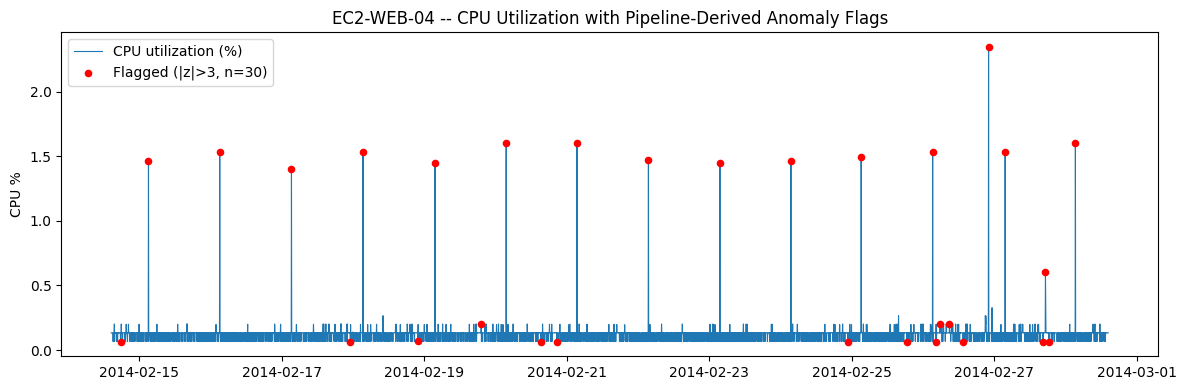

In [ ]:
conn = sqlite3.connect(DB_PATH)
sample = pd.read_sql(
    "SELECT * FROM fact_metric WHERE asset_id = 'EC2-WEB-04' ORDER BY timestamp", conn,
    parse_dates=["timestamp"]
)
conn.close()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample["timestamp"], sample["value"], label="CPU utilization (%)", linewidth=0.8)
flagged = sample[sample["zscore_1h"].abs() > 3]
ax.scatter(flagged["timestamp"], flagged["value"], color="red", s=20, zorder=5, label=f"Flagged (|z|>3, n={len(flagged)})")
ax.set_title("EC2-WEB-04 -- CPU Utilization with Pipeline-Derived Anomaly Flags")
ax.set_ylabel("CPU %")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion

### Summary

This notebook builds a complete data engineering pipeline for infrastructure telemetry: real,
multi-source server metrics are extracted via a config-driven registry, validated against explicit
data-quality checks, transformed into a monitoring-ready form, and loaded into a star-schema
warehouse — with production orchestration, pipeline health monitoring, and a worked example of
downstream consumption, all demonstrated against genuine data rather than illustrative toy examples.

### What was built

- A **config-driven, multi-source extract layer** (4 real AWS CloudWatch metric sources, onboarded
  via `config/sources.yaml` rather than code changes)
- A **validation gate** with duplicate/null/range checks, proven against both real and deliberately
  injected bad data
- A **transform layer** handling gap-filling and monitoring-relevant feature engineering
- A **star-schema warehouse load** (SQLite here; the schema design translates directly to Postgres,
  Redshift, or BigQuery in production)
- A real, deployable **Airflow DAG** with fail-loudly alerting logic
- A **pipeline monitoring log** table and threshold-based alerting
- A worked example of the warehouse output feeding a downstream anomaly-flagging use case

### Key takeaways

- **Data engineering is largely about handling failure gracefully.** Most of the code in this
  notebook exists to detect and handle things going wrong (duplicates, gaps, corrupted values,
  pipeline failures) rather than the "happy path" of moving clean data from A to B.
- **Configuration should live outside code.** The source registry lives in a YAML file specifically
  so the pipeline can grow without redeployment — a small design choice with an outsized effect on
  who can safely operate the system.
- **A pipeline should be able to explain itself.** The `pipeline_runs` monitoring table exists because
  a pipeline that fails or degrades silently is far more dangerous than one that fails loudly and
  visibly.

### Known limitations and possible extensions

This project is scoped to be runnable and inspectable end-to-end rather than to replicate
production infrastructure at scale. Honestly stated, a production version would likely differ in:

- **Ingestion**: real high-velocity telemetry would use a streaming layer (Kafka/Kinesis) rather than
  batch-polling flat files
- **Storage**: a cloud data warehouse (Postgres/Redshift/BigQuery) or a purpose-built time-series
  database, in place of SQLite
- **Validation**: a dedicated data-quality framework (e.g. Great Expectations) for more expressive,
  versioned rules than the threshold checks used here
- **Transformation at scale**: Spark or dbt in place of pandas, once data volume exceeds what fits in
  memory

Natural next steps building on this pipeline include wiring its output into a live BI dashboard, and
extending the anomaly-flagging example in Section 7 into a fully monitored, deployed model — the kind
of MLOps lifecycle (experiment tracking, model registry, deployment, drift monitoring) that a model
consuming this pipeline's output would need once it's expected to run continuously rather than in a
single notebook run.